In [2]:
import pandas as pd
import numpy as np
from huggingface_hub import hf_hub_download
from kaggle_secrets import UserSecretsClient
from rich import print as rprint

user_secrets = UserSecretsClient()
HF_TOKEN = user_secrets.get_secret("HF_TOKEN")

catalog_path = hf_hub_download(
    repo_id = "Subhadip007/UERP_Dataset",
    filename = "unified_catalog_v1.parquet",
    repo_type = "dataset",
    token = HF_TOKEN,
)

catalog = pd.read_parquet(catalog_path)

rprint(f"Shape: {catalog.shape}")
rprint()
rprint(catalog.info())

unified_catalog_v1.parquet:   0%|          | 0.00/10.5M [00:00<?, ?B/s]

Shape: (39664, 12)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39664 entries, 0 to 39663
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   content_id         39664 non-null  object 
 1   is_anime           39664 non-null  bool   
 2   title              39664 non-null  object 
 3   content_type       39664 non-null  object 
 4   year               39503 non-null  float64
 5   genres             39664 non-null  object 
 6   overview           39660 non-null  object 
 7   rating_normalized  39571 non-null  float64
 8   popularity_signal  39664 non-null  int64  
 9   poster_url         39572 non-null  object 
 10  runtime_minutes    33703 non-null  object 
 11  episodes           4797 non-null   float64
dtypes: bool(1), float64(3), int64(1), object(7)
memory usage: 3.4+ MB


None

In [3]:
missing = pd.DataFrame(
    {
        "null_count": catalog.isna().sum(),
        "null_pct": (catalog.isna().sum() / len(catalog) * 100).round(2)
    }
).sort_values("null_count", ascending = False)

rprint(missing)

null_count  null_pct
episodes                34867     87.91
runtime_minutes          5961     15.03
year                      161      0.41
rating_normalized          93      0.23
poster_url                 92      0.23
overview                    4      0.01
is_anime                    0      0.00
content_id                  0      0.00
content_type                0      0.00
title                       0      0.00
genres                      0      0.00
popularity_signal           0      0.00

In [4]:
display(catalog.head(3))

,content_id,is_anime,title,content_type,year,genres,overview,rating_normalized,popularity_signal,poster_url,runtime_minutes,episodes
0,imdb_tt0111161,False,The Shawshank Redemption,movie,1994.0,[Drama],Imprisoned in the 1940s for the double murder ...,9.3,3208129,https://image.tmdb.org/t/p/w500/9cqNxx0GxF0bfl...,142,NaN
1,imdb_tt0468569,False,The Dark Knight,movie,2008.0,"[Crime, Thriller]",Batman raises the stakes in his war on crime. ...,9.1,3189287,https://image.tmdb.org/t/p/w500/qJ2tW6WMUDux91...,152,NaN
2,imdb_tt1375666,False,Inception,movie,2010.0,"[Adventure, Science Fiction, Thriller]","Cobb, a skilled thief who commits corporate es...",8.8,2835072,https://image.tmdb.org/t/p/w500/xlaY2zyzMfkhk0...,148,NaN


In [5]:
catalog['runtime_minutes'] = pd.to_numeric(catalog['runtime_minutes'], errors = 'coerce')

rprint(catalog['runtime_minutes'].dtype)
rprint(catalog['runtime_minutes'].describe())

float64

count    33703.000000
mean        86.062012
std         45.435916
min          1.000000
25%         58.000000
50%         92.000000
75%        110.000000
max       1611.000000
Name: runtime_minutes, dtype: float64

### **Genre Distribution**

In [6]:
genre_counts = catalog['genres'].explode().value_counts()

rprint(f"Total unique genres: {genre_counts.shape[0]}")
rprint()
rprint(genre_counts)

Total unique genres: 32

genres
Drama              19848
Comedy             15248
Action              8995
Romance             6411
Crime               6253
Adventure           6189
Thriller            4311
Fantasy             3917
Mystery             3869
Horror              3579
Animation           3567
Science Fiction     2692
Family              2283
Documentary         1977
Biography           1843
History             1441
Music               1203
Slice of Life       1118
Sports              1047
Supernatural         988
War                  656
Ecchi                546
Musical              399
Reality              394
Psychological        390
Western              313
Mecha                279
Game-Show            185
Film-Noir            152
Mahou Shoujo         135
Talk Show            115
News                  49
Name: count, dtype: int64

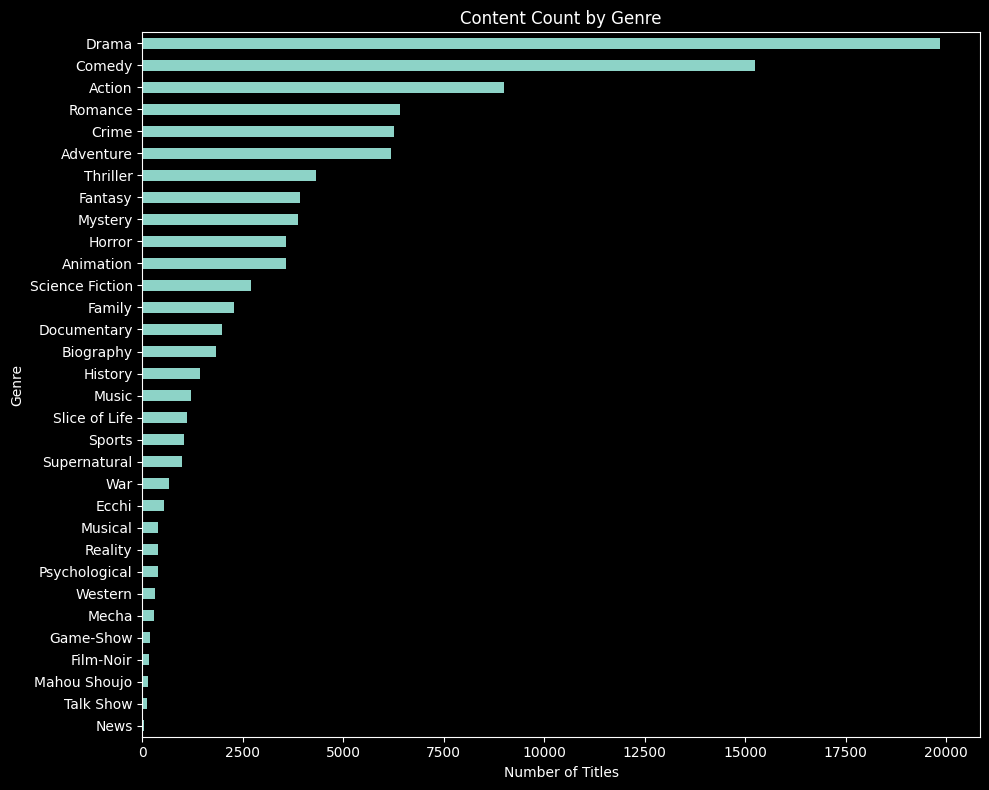

In [7]:
import matplotlib.pyplot as plt

plt.style.use("dark_background")

plt.figure(figsize=(10, 8))
genre_counts.sort_values().plot(kind = "barh")

plt.title("Content Count by Genre")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()

In [8]:
rprint("--- Non-anime top genres ---")
rprint(catalog[~catalog['is_anime']]['genres'].explode().value_counts().head(10))
rprint()
rprint("--- Anime top genres ---")
rprint(catalog[catalog['is_anime']]['genres'].explode().value_counts().head(10))

--- Non-anime top genres ---

genres
Drama        18261
Comedy       12962
Action        6839
Crime         6253
Romance       5092
Adventure     5022
Thriller      4147
Animation     3567
Horror        3372
Mystery       3348
Name: count, dtype: int64

--- Anime top genres ---

genres
Comedy             2286
Action             2156
Drama              1587
Fantasy            1566
Romance            1319
Adventure          1167
Slice of Life      1118
Supernatural        988
Science Fiction     957
Ecchi               546
Name: count, dtype: int64

In [9]:
extreme_runtime = catalog[
    (catalog['runtime_minutes'] > 300) | (catalog['runtime_minutes'] < 3)
].sort_values('runtime_minutes', ascending = False)

rprint("Extreme runtime count:", extreme_runtime.shape[0])
rprint(extreme_runtime[['title', 'content_type', 'runtime_minutes', 'year']].head(20))

Extreme runtime count: 176

title   content_type  \
20064                                      The Bear      tv_series   
26845                                 Último a Sair      tv_series   
25694                                  Jack & Bobby      tv_series   
26332                            My Lovely Sam-Soon      tv_series   
31982                                      Live Aid     tv_special   
22898                       The Life & Times of Tim      tv_series   
23732                           The Time in Between      tv_series   
26012  Roughnecks: The Starship Troopers Chronicles      tv_series   
27196                             My Uncle Napoleon      tv_series   
19787                       Europa: The Last Battle          movie   
22279                   That Mitchell and Webb Look      tv_series   
25300                       The American Revolution      tv_series   
29608                                  Nightingales  tv_miniseries   
22507                                   Wolf's Rain      tv_series   
28373                              Kingdom Hospital  tv_miniseries   
27679                                   Desert Punk      tv_series   
27203                             Toate pânzele sus      tv_series   
11406                                         Shoah          movie   
26626                                Marble Hornets      tv_series   
27494                           The Penal Battalion      tv_series   

       runtime_minutes    year  
20064           1611.0  2022.0  
26845           1210.0  2011.0  
25694            967.0  2004.0  
26332            960.0  2005.0  
31982            960.0  1985.0  
22898            900.0  2008.0  
23732            853.0  2013.0  
26012            778.0  1999.0  
27196            770.0  1976.0  
19787            746.0  2017.0  
22279            720.0  2006.0  
25300            720.0  2025.0  
29608            720.0  1988.0  
22507            701.0  2003.0  
28373            608.0  2004.0  
27679            580.0  2004.0  
27203            568.0  1977.0  
11406            566.0  1985.0  
26626            558.0  2009.0  
27494            550.0  2004.0

In [10]:
print("Duplicate content_id:", catalog['content_id'].duplicated().sum())

dup_title_year = catalog[catalog.duplicated(subset = ['title', 'year'], keep = False)].sort_values('title')
rprint("Same title+year entries:", dup_title_year.shape[0])
rprint(dup_title_year[['content_id', 'title', 'year', 'content_type', 'is_anime']].head(20))

Duplicate content_id: 0


Same title+year entries: 1483

content_id                                 title    year  \
3541    imdb_tt0983213              5 Centimeters per Second  2007.0   
34965     anilist_1689              5 Centimeters per Second  2007.0   
28430   imdb_tt5839706                               91 Days  2016.0   
35052    anilist_21711                               91 Days  2016.0   
35077     anilist_4654               A Certain Magical Index  2008.0   
25721   imdb_tt1308089               A Certain Magical Index  2008.0   
26284   imdb_tt1515996          A Certain Scientific Railgun  2009.0   
35190     anilist_6213          A Certain Scientific Railgun  2009.0   
25077  imdb_tt14400866                   A Couple of Cuckoos  2022.0   
35399   anilist_132052                   A Couple of Cuckoos  2022.0   
37536    anilist_10389                      A Letter to Momo  2011.0   
13496   imdb_tt1853614                      A Letter to Momo  2011.0   
27525   imdb_tt3104236                     A Lull in the Sea  2013.0   
35249    anilist_16067                     A Lull in the Sea  2013.0   
35152    anilist_99426     A Place Further Than the Universe  2018.0   
28917   imdb_tt7836688     A Place Further Than the Universe  2018.0   
27453  imdb_tt28313387  A Returner's Magic Should Be Special  2023.0   
35881   anilist_163142  A Returner's Magic Should Be Special  2023.0   
28670  imdb_tt30024091                   A Sign of Affection  2024.0   
35256   anilist_166794                   A Sign of Affection  2024.0   

        content_type  is_anime  
3541           movie     False  
34965          movie      True  
28430  tv_miniseries     False  
35052      tv_series      True  
35077      tv_series      True  
25721      tv_series     False  
26284      tv_series     False  
35190      tv_series      True  
25077      tv_series     False  
35399      tv_series      True  
37536          movie      True  
13496          movie     False  
27525      tv_series     False  
35249      tv_series      True  
35152      tv_series      True  
28917  tv_miniseries     False  
27453      tv_series     False  
35881      tv_series      True  
28670  tv_miniseries     False  
35256      tv_series      True

In [11]:
import requests
import os
import time
from concurrent.futures import ThreadPoolExecutor, as_completed

TMDB_API_KEY = user_secrets.get_secret("TMDB_API_KEY")

os.makedirs('/kaggle/working/processed', exist_ok = True)
LANG_CHECKPOINT_PATH = '/kaggle/working/processed/tmdb_language.parquet'

imdb_rows = catalog[~catalog['is_anime']].copy()
imdb_rows['tconst'] = imdb_rows['content_id'].str.replace('imdb_', '', regex = False)

rprint("IMDb rows to enrich:", imdb_rows.shape[0])
rprint(imdb_rows[['content_id', 'tconst']].head())

IMDb rows to enrich: 34763

content_id     tconst
0  imdb_tt0111161  tt0111161
1  imdb_tt0468569  tt0468569
2  imdb_tt1375666  tt1375666
3  imdb_tt0137523  tt0137523
4  imdb_tt0816692  tt0816692

In [12]:
def fetch_language_by_imdb_id(imdb_id, api_key):
    url = f"https://api.themoviedb.org/3/find/{imdb_id}"
    params = {
        "api_key": api_key,
        "external_source": "imdb_id"
    }
    try:
        resp = requests.get(url, params = params, timeout = 10)
        if resp.status_code != 200:
            return imdb_id, None, f"HTTP {resp.status_code}"
        data = resp.json()
        results = data.get('movie_results') or data.get('tv_results')
        if not results:
            return imdb_id, None, "no_match"
        r = results[0]
        return imdb_id, {'original_language': r.get('original_language')}, None
    except Exception as e:
        return imdb_id, None, str(e)

def load_lang_checkpoint():
    if os.path.exists(LANG_CHECKPOINT_PATH):
        df = pd.read_parquet(LANG_CHECKPOINT_PATH)
        return df, set(df['tconst'])
    return pd.DataFrame(), set()

def run_language_enrichment(target_df, api_key):
    lang_df, done_ids = load_lang_checkpoint()
    todo = target_df[~target_df['tconst'].isin(done_ids)]
    total = len(todo)
    rprint(f"Already done: {len(done_ids)} | Remaining: {total}")

    for start in range(0, total, 500):
        batch = todo.iloc[start:start+500]
        batch_results = []
        with ThreadPoolExecutor(max_workers=8) as executor:
            futures = {
                executor.submit(fetch_language_by_imdb_id, row['tconst'], api_key): row
                for _, row in batch.iterrows()
            }
            for future in as_completed(futures):
                row = futures[future]
                imdb_id, data, error = future.result()
                if data:
                    batch_results.append(
                        {
                            'tconst': imdb_id, 
                            **data
                        }
                    )

        new_df = pd.DataFrame(batch_results)
        lang_df = pd.concat([lang_df, new_df], ignore_index = True) if not lang_df.empty else new_df
        lang_df.to_parquet(LANG_CHECKPOINT_PATH, index = False)
        rprint(f"Checkpoint: {min(start+500, total)}/{total}")
        time.sleep(0.5)

    return lang_df

In [13]:
lang_result = run_language_enrichment(imdb_rows[['tconst']], TMDB_API_KEY)
rprint(lang_result.shape)
rprint(lang_result['original_language'].value_counts().head(15))

Already done: 0 | Remaining: 34763

Checkpoint: 500/34763

Checkpoint: 1000/34763

Checkpoint: 1500/34763

Checkpoint: 2000/34763

...

Checkpoint: 33500/34763

Checkpoint: 34000/34763

Checkpoint: 34500/34763

Checkpoint: 34763/34763

(34752, 2)
original_language
en    24616
hi     1471
ja     1396
fr     1192
ko      704
tr      643
es      642
it      436
de      425
ru      283
ta      274
zh      267
sv      235
te      208
ml      161
Name: count, dtype: int64


In [14]:
ANILIST_URL = "https://graphql.anilist.co"

ANILIST_QUERY_V2 = """
query ($page: Int, $perPage: Int) {
  Page(page: $page, perPage: $perPage) {
    pageInfo { total currentPage lastPage hasNextPage }
    media(type: ANIME, sort: POPULARITY_DESC) {
      id
      countryOfOrigin
    }
  }
}
"""

def fetch_anilist_country(page, per_page = 50):
    resp = requests.post(ANILIST_URL, json = {"query": ANILIST_QUERY_V2, "variables": {"page": page, "perPage": per_page}}, timeout = 15)
    if resp.status_code == 200:
        return resp.json()
    return None

country_records = []

for page in range(1, 101):
    data = fetch_anilist_country(page)
    if data is None:
        continue
    for item in data.get('data', {}).get('Page', {}).get('media', []):
        country_records.append({'anilist_id': item.get('id'), 'countryOfOrigin': item.get('countryOfOrigin')})
    time.sleep(0.8)

In [15]:
anilist_country_df = pd.DataFrame(country_records)
rprint(anilist_country_df.shape)
rprint(anilist_country_df['countryOfOrigin'].value_counts())

(1500, 2)

countryOfOrigin
JP    1489
CN      11
Name: count, dtype: int64

In [16]:
CHECKPOINT_PATH_COUNTRY = '/kaggle/working/processed/anilist_country.parquet'

def fetch_anilist_country_safe(page, per_page = 50, max_retries = 4):
    for attempt in range(max_retries):
        resp = requests.post(
            ANILIST_URL,
            json={"query": ANILIST_QUERY_V2, "variables": {"page": page, "perPage": per_page}},
            timeout = 15,
        )
        if resp.status_code == 200:
            return resp.json()
        elif resp.status_code == 429:
            retry_after = int(resp.headers.get("Retry-After", 60))
            rprint(f"Page {page}: rate limited, waiting {retry_after}s")
            time.sleep(retry_after)
        elif resp.status_code in (500, 502, 503, 504):
            wait = 2 ** attempt
            rprint(f"Page {page}: got {resp.status_code}, retrying in {wait}s")
            time.sleep(wait)
        else:
            rprint(f"Page {page}: non-retryable {resp.status_code} - {resp.text[:150]}")
            return None
    rprint(f"Page {page}: failed after {max_retries} retries")
    return None

def load_country_checkpoint():
    if os.path.exists(CHECKPOINT_PATH_COUNTRY):
        df = pd.read_parquet(CHECKPOINT_PATH_COUNTRY)
        return df, set(df['_source_page'])
    return pd.DataFrame(), set()

def run_country_pull(total_pages=100):
    all_df, done_pages = load_country_checkpoint()
    rprint(f"Already done pages: {len(done_pages)}")
    buffer = []

    for page in range(1, total_pages + 1):
        if page in done_pages:
            continue
        data = fetch_anilist_country_safe(page)
        if data is None:
            continue   
        for item in data.get('data', {}).get('Page', {}).get('media', []):
            buffer.append(
                {
                    'anilist_id': item.get('id'),
                    'countryOfOrigin': item.get('countryOfOrigin'),
                    '_source_page': page,
                }
            )
        time.sleep(0.8)

        if page % 20 == 0:
            new_df = pd.DataFrame(buffer)
            all_df = pd.concat([all_df, new_df], ignore_index = True) if not all_df.empty else new_df
            all_df.to_parquet(CHECKPOINT_PATH_COUNTRY, index = False)
            buffer = []
            rprint(f"Checkpoint saved: page {page}/{total_pages} | rows: {len(all_df)}")

    if buffer:
        new_df = pd.DataFrame(buffer)
        all_df = pd.concat([all_df, new_df], ignore_index = True) if not all_df.empty else new_df
        all_df.to_parquet(CHECKPOINT_PATH_COUNTRY, index = False)
        rprint(f"Final checkpoint | total rows: {len(all_df)}")

    return all_df

anilist_country_df = run_country_pull(total_pages = 100)
rprint(anilist_country_df.shape)
rprint(anilist_country_df['countryOfOrigin'].value_counts())

Already done pages: 0

Checkpoint saved: page 20/100 | rows: 1000

Page 31: rate limited, waiting 29s

Checkpoint saved: page 40/100 | rows: 2000

Checkpoint saved: page 60/100 | rows: 3000

...

Checkpoint saved: page 80/100 | rows: 4000

Page 91: rate limited, waiting 28s

Checkpoint saved: page 100/100 | rows: 5000

(5000, 3)

countryOfOrigin
JP    4912
CN      79
KR       9
Name: count, dtype: int64

In [18]:
imdb_lang = lang_result.copy()
imdb_lang['content_id'] = 'imdb_' + imdb_lang['tconst']
imdb_lang = imdb_lang[['content_id', 'original_language']]

anime_country = anilist_country_df.copy()
anime_country['content_id'] = 'anilist_' + anime_country['anilist_id'].astype(str)
anime_country = anime_country[['content_id', 'countryOfOrigin']].drop_duplicates('content_id')

catalog = catalog.merge(imdb_lang, on = 'content_id', how = 'left')
catalog = catalog.merge(anime_country, on = 'content_id', how = 'left')

rprint(catalog.shape)
rprint(catalog[['content_id', 'is_anime', 'original_language', 'countryOfOrigin']].sample(5))

(39664, 14)

content_id  is_anime original_language countryOfOrigin
36360   anilist_20951      True               NaN              JP
31945  imdb_tt1935828     False                en             NaN
11643  imdb_tt1514041     False                en             NaN
14998  imdb_tt6910678     False                en             NaN
14314  imdb_tt0963965     False                en             NaN

In [19]:
country_to_lang = {
    'JP': 'ja', 
    'CN': 'zh', 
    'KR': 'ko'
}

catalog['language'] = catalog['original_language']
anime_mask = catalog['is_anime']
catalog.loc[anime_mask, 'language'] = catalog.loc[anime_mask, 'countryOfOrigin'].map(country_to_lang)

catalog = catalog.drop(columns = ['original_language'])
catalog = catalog.rename(columns = {'countryOfOrigin': 'country'})

rprint("Language nulls:", catalog['language'].isnull().sum())
rprint()
rprint(catalog['language'].value_counts().head(15))
rprint()
rprint("Country nulls:", catalog['country'].isnull().sum(), "(expected - only anime has this for now)")

Language nulls: 12

language
en    24616
ja     6209
hi     1471
fr     1192
ko      712
tr      643
es      642
it      436
de      425
zh      346
ru      283
ta      274
sv      235
te      208
ml      161
Name: count, dtype: int64

Country nulls: 34764 (expected - only anime has this for now)

In [21]:
from huggingface_hub import HfApi, login

login(token = HF_TOKEN)
api = HfApi()


catalog.to_parquet('/kaggle/working/processed/unified_catalog_v2.parquet', index = False)

api.upload_file(
    path_or_fileobj = '/kaggle/working/processed/unified_catalog_v2.parquet',
    path_in_repo = 'unified_catalog_v2.parquet',
    repo_id = 'Subhadip007/UERP_Dataset',
    repo_type = 'dataset',
)

rprint("v2 pushed to HF Hub!")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

v2 pushed to HF Hub!

In [22]:
extreme_runtime = catalog[
    (catalog['runtime_minutes'] > 300) | (catalog['runtime_minutes'] < 3)
].sort_values('runtime_minutes', ascending = False)

rprint("Extreme runtime count:", extreme_runtime.shape[0])
rprint(extreme_runtime[['title', 'content_type', 'runtime_minutes', 'year']].head(20))

Extreme runtime count: 176

title   content_type  \
20064                                      The Bear      tv_series   
26845                                 Último a Sair      tv_series   
25694                                  Jack & Bobby      tv_series   
26332                            My Lovely Sam-Soon      tv_series   
31982                                      Live Aid     tv_special   
22898                       The Life & Times of Tim      tv_series   
23732                           The Time in Between      tv_series   
26012  Roughnecks: The Starship Troopers Chronicles      tv_series   
27196                             My Uncle Napoleon      tv_series   
19787                       Europa: The Last Battle          movie   
22279                   That Mitchell and Webb Look      tv_series   
25300                       The American Revolution      tv_series   
29608                                  Nightingales  tv_miniseries   
22507                                   Wolf's Rain      tv_series   
28373                              Kingdom Hospital  tv_miniseries   
27679                                   Desert Punk      tv_series   
27203                             Toate pânzele sus      tv_series   
11406                                         Shoah          movie   
26626                                Marble Hornets      tv_series   
27494                           The Penal Battalion      tv_series   

       runtime_minutes    year  
20064           1611.0  2022.0  
26845           1210.0  2011.0  
25694            967.0  2004.0  
26332            960.0  2005.0  
31982            960.0  1985.0  
22898            900.0  2008.0  
23732            853.0  2013.0  
26012            778.0  1999.0  
27196            770.0  1976.0  
19787            746.0  2017.0  
22279            720.0  2006.0  
25300            720.0  2025.0  
29608            720.0  1988.0  
22507            701.0  2003.0  
28373            608.0  2004.0  
27679            580.0  2004.0  
27203            568.0  1977.0  
11406            566.0  1985.0  
26626            558.0  2009.0  
27494            550.0  2004.0

In [23]:
rprint("Duplicate content_id:", catalog['content_id'].duplicated().sum())

dup_title_year = catalog[catalog.duplicated(subset = ['title', 'year'], keep = False)].sort_values('title')

rprint("Same title+year entries:", dup_title_year.shape[0])
rprint(dup_title_year[['content_id', 'title', 'year', 'content_type', 'is_anime']].head(20))

Duplicate content_id: 0

Same title+year entries: 1483

content_id                                 title    year  \
3541    imdb_tt0983213              5 Centimeters per Second  2007.0   
34965     anilist_1689              5 Centimeters per Second  2007.0   
28430   imdb_tt5839706                               91 Days  2016.0   
35052    anilist_21711                               91 Days  2016.0   
35077     anilist_4654               A Certain Magical Index  2008.0   
25721   imdb_tt1308089               A Certain Magical Index  2008.0   
26284   imdb_tt1515996          A Certain Scientific Railgun  2009.0   
35190     anilist_6213          A Certain Scientific Railgun  2009.0   
25077  imdb_tt14400866                   A Couple of Cuckoos  2022.0   
35399   anilist_132052                   A Couple of Cuckoos  2022.0   
37536    anilist_10389                      A Letter to Momo  2011.0   
13496   imdb_tt1853614                      A Letter to Momo  2011.0   
27525   imdb_tt3104236                     A Lull in the Sea  2013.0   
35249    anilist_16067                     A Lull in the Sea  2013.0   
35152    anilist_99426     A Place Further Than the Universe  2018.0   
28917   imdb_tt7836688     A Place Further Than the Universe  2018.0   
27453  imdb_tt28313387  A Returner's Magic Should Be Special  2023.0   
35881   anilist_163142  A Returner's Magic Should Be Special  2023.0   
28670  imdb_tt30024091                   A Sign of Affection  2024.0   
35256   anilist_166794                   A Sign of Affection  2024.0   

        content_type  is_anime  
3541           movie     False  
34965          movie      True  
28430  tv_miniseries     False  
35052      tv_series      True  
35077      tv_series      True  
25721      tv_series     False  
26284      tv_series     False  
35190      tv_series      True  
25077      tv_series     False  
35399      tv_series      True  
37536          movie      True  
13496          movie     False  
27525      tv_series     False  
35249      tv_series      True  
35152      tv_series      True  
28917  tv_miniseries     False  
27453      tv_series     False  
35881      tv_series      True  
28670  tv_miniseries     False  
35256      tv_series      True

In [24]:
rprint(extreme_runtime[extreme_runtime['runtime_minutes'] < 3][['title', 'content_type', 'runtime_minutes', 'year']])

title   content_type  \
23873                                          Bref.      tv_series   
25103  Seth MacFarlane's Cavalcade of Cartoon Comedy      tv_series   
27793                      Descendants: Wicked World      tv_series   
28704                       The Originals: Awakening  tv_miniseries   
32881                                The Illusionist          short   
...                                              ...            ...   
34233                                       Eye Myth          short   
34253                                         Sandow          short   
34292                                  Batman Beyond          short   
34550                         Arnold Rides His Chair          short   
34488                               The Calligrapher          short   

       runtime_minutes    year  
23873              2.0  2011.0  
25103              2.0  2008.0  
27793              2.0  2015.0  
28704              2.0  2013.0  
32881              2.0  2009.0  
...                ...     ...  
34233              1.0  1977.0  
34253              1.0  1896.0  
34292              1.0  2014.0  
34550              1.0  1991.0  
34488              1.0  1991.0  

[108 rows x 4 columns]

In [25]:
pattern_check = dup_title_year.groupby(['title', 'year'])['is_anime'].nunique()
rprint("Groups with exactly one anime + one non-anime match:", (pattern_check == 2).sum())
rprint("Groups where BOTH entries are same type (genuine coincidence, don't touch):", (pattern_check == 1).sum())

coincidence_titles = pattern_check[pattern_check == 1].index
if len(coincidence_titles) > 0:
    coincidence_df = dup_title_year.set_index(['title','year']).loc[coincidence_titles].reset_index()
    rprint(coincidence_df[['content_id', 'title', 'year', 'is_anime']].head(10))

Groups with exactly one anime + one non-anime match: 670

Groups where BOTH entries are same type (genuine coincidence, don't touch): 70

content_id                        title    year  is_anime
0   imdb_tt0086662                      Airwolf  1984.0     False
1   imdb_tt0086862                      Airwolf  1984.0     False
2   imdb_tt7711170                        Alone  2020.0     False
3  imdb_tt10192566                        Alone  2020.0     False
4   imdb_tt7456310                         Anna  2019.0     False
5   imdb_tt9842732                         Anna  2019.0     False
6   imdb_tt0096536  Around the World in 80 Days  1989.0     False
7   imdb_tt0096535  Around the World in 80 Days  1989.0     False
8   imdb_tt0077215         Battlestar Galactica  1978.0     False
9   imdb_tt0076984         Battlestar Galactica  1978.0     False

In [26]:
mixed_pairs = pattern_check[pattern_check == 2].index

rows_in_mixed = dup_title_year.set_index(['title', 'year']).index.isin(mixed_pairs)
mixed_subset = dup_title_year[rows_in_mixed]

group_sizes = mixed_subset.groupby(['title', 'year']).size()
rprint("Group size distribution:")
rprint(group_sizes.value_counts())

Group size distribution:

2    667
3      3
Name: count, dtype: int64

In [27]:
drop_content_ids = mixed_subset[mixed_subset['is_anime'] == False]['content_id']
rprint("Rows to drop:", len(drop_content_ids))

catalog_deduped = catalog[~catalog['content_id'].isin(drop_content_ids)].copy()
rprint("Before:", catalog.shape[0], "| After dedup:", catalog_deduped.shape[0])

catalog = catalog_deduped

Rows to drop: 673

Before: 39664 | After dedup: 38991

In [28]:
size3_titles = group_sizes[group_sizes == 3].index
for title, year in size3_titles:
    rprint(mixed_subset[(mixed_subset['title'] == title) & (mixed_subset['year'] == year)][
        ['content_id', 'title', 'year', 'content_type', 'is_anime']
    ])
    rprint('---')

content_id       title    year content_type  is_anime
20026  imdb_tt0877057  Death Note  2006.0    tv_series     False
6032   imdb_tt0758742  Death Note  2006.0        movie     False
34766    anilist_1535  Death Note  2006.0    tv_series      True

---

content_id      title    year content_type  is_anime
8084   imdb_tt31015496  The Fable  2024.0        movie     False
26893  imdb_tt28329410  The Fable  2024.0    tv_series     False
36652   anilist_166910  The Fable  2024.0    tv_series      True

---

content_id                             title    year  \
34989   anilist_159831  Zom 100: Bucket List of the Dead  2023.0   
28184  imdb_tt25811262  Zom 100: Bucket List of the Dead  2023.0   
13934  imdb_tt20672534  Zom 100: Bucket List of the Dead  2023.0   

        content_type  is_anime  
34989      tv_series      True  
28184  tv_miniseries     False  
13934          movie     False

---

In [29]:
false_positive_ids = ['tt0758742', 'tt31015496', 'tt20672534']

drop_content_ids_corrected = drop_content_ids[
    ~drop_content_ids.str.replace('imdb_', '', regex = False).isin(false_positive_ids)
]

rprint("Original drop count:", len(drop_content_ids))
rprint("Corrected drop count:", len(drop_content_ids_corrected))

catalog_deduped = catalog[~catalog['content_id'].isin(drop_content_ids_corrected)].copy()
rprint("Before:", catalog.shape[0], "| After corrected dedup:", catalog_deduped.shape[0])

catalog = catalog_deduped

Original drop count: 673

Corrected drop count: 670

Before: 38991 | After corrected dedup: 38991

In [30]:
catalog_path_v2 = hf_hub_download(
    repo_id = "Subhadip007/UERP_Dataset",
    filename = "unified_catalog_v2.parquet",
    repo_type = "dataset",
    token = HF_TOKEN,
)

catalog = pd.read_parquet(catalog_path_v2)
rprint("Fresh reload:", catalog.shape)   # expect (39664, 14)

catalog_deduped = catalog[~catalog['content_id'].isin(drop_content_ids_corrected)].copy()
rprint("Before:", catalog.shape[0], "| After corrected dedup:", catalog_deduped.shape[0])

catalog = catalog_deduped

unified_catalog_v2.parquet:   0%|          | 0.00/10.5M [00:00<?, ?B/s]

Fresh reload:
(39664, 14)

Before: 39664 | After corrected dedup: 38994

In [31]:
catalog.to_parquet('/kaggle/working/processed/unified_catalog_v3.parquet', index = False)

api.upload_file(
    path_or_fileobj = '/kaggle/working/processed/unified_catalog_v3.parquet',
    path_in_repo = 'unified_catalog_v3.parquet',
    repo_id = 'Subhadip007/UERP_Dataset',
    repo_type = 'dataset',
)

rprint("v3 pushed to HF Hub!")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

v3 pushed to HF Hub!

In [32]:
import numpy as np

# --- Year distribution ---
rprint("--- Year ---")
rprint(catalog['year'].describe())
rprint()
rprint("Titles per decade:")
decade = (catalog['year'] // 10 * 10).dropna().astype(int)
rprint(decade.value_counts().sort_index())

--- Year ---

count    38833.000000
mean      2005.375377
std         20.440465
min       1874.000000
25%       1999.000000
50%       2012.000000
75%       2019.000000
max       2027.000000
Name: year, dtype: float64

Titles per decade:

year
1870        1
1880        5
1890       52
1900       46
1910       90
1920      140
1930      318
1940      511
1950      670
1960      927
1970     1346
1980     2180
1990     3550
2000     6996
2010    12902
2020     9099
Name: count, dtype: int64

In [33]:
# --- Rating distribution ---
rprint("--- Rating (normalized 0-10) ---")
rprint(catalog['rating_normalized'].describe())
rprint()
rprint("Anime vs non-anime rating comparison:")
rprint(catalog.groupby('is_anime')['rating_normalized'].describe())

--- Rating (normalized 0-10) ---

count    38901.000000
mean         6.755078
std          1.074245
min          1.000000
25%          6.200000
50%          6.900000
75%          7.500000
max          9.600000
Name: rating_normalized, dtype: float64

Anime vs non-anime rating comparison:

count      mean       std  min  25%  50%  75%  max
is_anime                                                      
False     34093.0  6.719943  1.101799  1.0  6.1  6.8  7.5  9.6
True       4808.0  7.004222  0.811274  1.6  6.5  7.0  7.6  9.1

In [34]:
# --- Popularity distribution (numVotes for movies/TV, members-based for anime - NOTE: different scales!) ---
rprint("--- Popularity signal (raw) ---")
rprint(catalog.groupby('is_anime')['popularity_signal'].describe())

--- Popularity signal (raw) ---

count          mean            std     min      25%      50%  \
is_anime                                                                   
False     34093.0  40393.174171  121113.821737    62.0   4392.0   8504.0   
True       4901.0  58237.328504   91301.497636  6970.0  13123.0  26430.0   

              75%        max  
is_anime                      
False     24887.0  3208129.0  
True      60273.0  1030730.0

In [35]:
rprint("Suspiciously early years:")
rprint(catalog[catalog['year'] < 1880][['content_id', 'title', 'year', 'content_type']])
rprint()

rprint("Future years (>2026):")
future = catalog[catalog['year'] > 2026]
rprint(future.shape[0], "titles")
rprint(future[['content_id', 'title', 'year', 'content_type', 'rating_normalized', 'popularity_signal']].head(15))

Suspiciously early years:

content_id             title    year content_type
33270  imdb_tt3155794  Passage of Venus  1874.0        short

Future years (>2026):

10 titles

content_id                                              title  \
36477  anilist_178031                      Delicious in Dungeon Season 2   
36647  anilist_209939                       Sousou no Frieren 3rd Season   
37045  anilist_189323                     Shangri-La Frontier 3rd Season   
37086  anilist_177704  MASHLE: Sanma Taisou Shinkakusha Saishuu Shike...   
37316  anilist_211496                                        Kagurabachi   
37789  anilist_204363                             SAKAMOTO DAYS Season 2   
37950  anilist_186822  The Guy She Was Interested In Wasn't a Guy At All   
39035  anilist_200927           Kusuriya no Hitorigoto 3rd Season Part 2   
39107  anilist_213752                           MARRIAGETOXIN 2nd Season   
39564  anilist_188892  Kuroiwa Medaka ni Watashi no Kawaii ga Tsuujin...   

         year content_type  rating_normalized  popularity_signal  
36477  2027.0   tv_special                NaN              41988  
36647  2027.0    tv_series                NaN              37583  
37045  2027.0    tv_series                NaN              29296  
37086  2027.0    tv_series                NaN              28462  
37316  2027.0    tv_series                NaN              24909  
37789  2027.0    tv_series                NaN              18840  
37950  2027.0    tv_series                NaN              17155  
39035  2027.0    tv_series                NaN               9552  
39107  2027.0    tv_series                NaN               9214  
39564  2027.0    tv_series                NaN               7348

In [36]:
future_ids = catalog[catalog['year'] > 2026]['content_id']
catalog = catalog[~catalog['content_id'].isin(future_ids)].copy()
rprint("Final catalog after future-date drop:", catalog.shape[0])

Final catalog after future-date drop: 38984

In [37]:
catalog.to_parquet('/kaggle/working/processed/unified_catalog_v4.parquet', index = False)

api.upload_file(
    path_or_fileobj = '/kaggle/working/processed/unified_catalog_v4.parquet',
    path_in_repo = 'unified_catalog_v4.parquet',
    repo_id = 'Subhadip007/UERP_Dataset',
    repo_type = 'dataset',
)

rprint("Final catalog (v4) pushed to HF Hub!")
rprint("Final shape:", catalog.shape)

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Final catalog (v4) pushed to HF Hub!

Final shape:
(38984, 14)